## Temporal Fusion Transformer

### 1. Setup and Imports

In [13]:
import os
import sys
import importlib
from pathlib import Path

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))
os.environ.setdefault("NIXTLA_ID_AS_COL", "1")

repo_root = Path.cwd()
while repo_root != repo_root.parent:
    if (repo_root / "src").exists():
        sys.path.insert(0, str(repo_root))
        break
    repo_root = repo_root.parent
else:
    raise FileNotFoundError("Could not locate the repository root containing 'src'.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.pyfunc
from mlflow.models import infer_signature

import wandb

from neuralforecast import NeuralForecast
from neuralforecast.models import TFT

import src.mlflow_setup as mlflow_setup
importlib.reload(mlflow_setup)
init_tracking = mlflow_setup.init_tracking
from src.data_loading import load_merged, load_features
from src.transforms import apply_shared_features
from src.validation import time_based_split
from src.metrics import wmae_from_df
from src.pipeline.tft_pipeline import to_long_format, to_static_format, TFTForecastPipeline, build_store_date_features
from src.training_diagnostics import GradientNormLogger, log_gradient_diagnostics

init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

if mlflow.active_run() is not None:
    mlflow.end_run()

BLUE = "#7196C7"
GREEN = "#5E9D74"
RED = "#7E3838"

print("Current MLflow URI:", mlflow.get_tracking_uri())
print("Setup complete.")


Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Current MLflow URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Setup complete.


### 2. Configuration

In [14]:
EXPERIMENT_NAME = "TFT_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

WANDB_ENTITY = "dkhak22-free-university-of-tbilisi-"
WANDB_PROJECT = "walmart-sales-forecasting"

CONFIG = {
    "input_size": 52,
    "horizon": 26,
    "hidden_size": 64,
    "n_head": 4,
    "dropout": 0.10,
    "learning_rate": 1e-3,
    "batch_size": 128,
    "max_steps": 500,
    "random_seed": 42,
}

FREQ = "W-FRI"
MODEL_COL = "TFT"

CONFIG


{'input_size': 52,
 'horizon': 26,
 'hidden_size': 64,
 'n_head': 4,
 'dropout': 0.1,
 'learning_rate': 0.001,
 'batch_size': 128,
 'max_steps': 500,
 'random_seed': 42}

### 3. Load Data

In [4]:
train_df, test_df = load_merged()

print(f"train_df: {train_df.shape}")
print(f"test_df:  {test_df.shape}")

CONFIG["horizon"] = test_df["Date"].nunique()
train_df.head()


train_df: (421570, 16)
test_df:  (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


### 4. Shared Preprocessing and Feature Engineering

In [5]:
train_prepared = apply_shared_features(train_df)

print(f"train_prepared: {train_prepared.shape}")
train_prepared.head()

train_prepared: (421570, 23)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Size,Type_A,Type_B,Type_C,Year,Month,WeekOfYear,DaysSinceLastHoliday,DaysToNextHoliday
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,5,inf,7.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,6,0.0,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,7,7.0,203.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,8,14.0,196.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,3,9,21.0,189.0


In [6]:
import numpy as np

inf_check = np.isinf(train_prepared.select_dtypes(include=[np.number])).sum()
print(inf_check[inf_check > 0])

for col in ["DaysSinceLastHoliday", "DaysToNextHoliday"]:
    if col in train_prepared.columns:
        finite_vals = train_prepared.loc[np.isfinite(train_prepared[col]), col]
        cap = finite_vals.max() if len(finite_vals) else 0
        train_prepared[col] = train_prepared[col].replace([np.inf, -np.inf], cap)

DaysSinceLastHoliday    2955
dtype: int64


### 5. Model-Specific Feature Selection

In [7]:
tft_exogenous_support = {
    "future_exogenous": getattr(TFT, "EXOGENOUS_FUTR", False),
    "historical_exogenous": getattr(TFT, "EXOGENOUS_HIST", False),
    "static_exogenous": getattr(TFT, "EXOGENOUS_STAT", False),
}

display(pd.Series(tft_exogenous_support, name="TFT exogenous support"))

FUTR_COLS = [
    "IsHoliday",
    "Temperature",
    "Fuel_Price",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "WeekOfYear",
    "DaysSinceLastHoliday",
    "DaysToNextHoliday",
]
FUTR_COLS = [col for col in FUTR_COLS if col in train_prepared.columns]

STATIC_COLS = ["Store", "Dept", "Size", "Type_A", "Type_B", "Type_C"]
STATIC_COLS = [col for col in STATIC_COLS if col in train_prepared.columns]

TFT_FEATURE_DECISION = {
    "feature_set": "future_and_static_exogenous",
    "uses_exogenous_features": True,
    "future_exogenous_columns": FUTR_COLS,
    "static_exogenous_columns": STATIC_COLS,
    "reason": (
        "TFT supports known future and static covariates, so this experiment uses "
        "calendar, holiday, markdown, economic, fuel, weather, store, and department features."
    ),
}

print("Future exogenous columns:", FUTR_COLS)
print("Static exogenous columns:", STATIC_COLS)
TFT_FEATURE_DECISION


future_exogenous        True
historical_exogenous    True
static_exogenous        True
Name: TFT exogenous support, dtype: bool

Future exogenous columns: ['IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Year', 'Month', 'WeekOfYear', 'DaysSinceLastHoliday', 'DaysToNextHoliday']
Static exogenous columns: ['Store', 'Dept', 'Size', 'Type_A', 'Type_B', 'Type_C']


{'feature_set': 'future_and_static_exogenous',
 'uses_exogenous_features': True,
 'future_exogenous_columns': ['IsHoliday',
  'Temperature',
  'Fuel_Price',
  'MarkDown1',
  'MarkDown2',
  'MarkDown3',
  'MarkDown4',
  'MarkDown5',
  'CPI',
  'Unemployment',
  'Year',
  'Month',
  'WeekOfYear',
  'DaysSinceLastHoliday',
  'DaysToNextHoliday'],
 'static_exogenous_columns': ['Store',
  'Dept',
  'Size',
  'Type_A',
  'Type_B',
  'Type_C'],
 'reason': 'TFT supports known future and static covariates, so this experiment uses calendar, holiday, markdown, economic, fuel, weather, store, and department features.'}

### 6. Time-Series and Window Setup

In [8]:
train_part, valid_part = time_based_split(train_prepared, valid_weeks=CONFIG["horizon"])

print(f"Train part: {train_part['Date'].min().date()} -> {train_part['Date'].max().date()}")
print(f"Valid part: {valid_part['Date'].min().date()} -> {valid_part['Date'].max().date()}")
print(f"\nInput size: {CONFIG['input_size']} weeks")
print(f"Forecast horizon: {CONFIG['horizon']} weeks")

long_df = to_long_format(train_prepared, include_target=True, futr_cols=FUTR_COLS)
series_lengths = long_df.groupby("unique_id").size()
TFT_SERIES_LENGTH = int(series_lengths.max())
tft_ids = series_lengths[series_lengths == TFT_SERIES_LENGTH].index
tft_df = long_df[long_df["unique_id"].isin(tft_ids)].copy()
static_df = to_static_format(train_prepared, static_cols=STATIC_COLS)
static_df = static_df[static_df["unique_id"].isin(tft_ids)].reset_index(drop=True)

print("\nSeries length summary:")
display(series_lengths.describe())
print("\nTFT training/evaluation frame:")
print(f"Using {tft_df['unique_id'].nunique()} complete-history Store-Dept series")
print(f"Dropping {long_df['unique_id'].nunique() - tft_df['unique_id'].nunique()} short/ragged series")
print(f"Rows used by TFT: {tft_df.shape[0]:,}")
print(f"Static rows used by TFT: {static_df.shape[0]:,}")

holiday_lookup = train_prepared.assign(
    unique_id=train_prepared["Store"].astype(str) + "_" + train_prepared["Dept"].astype(str),
    ds=train_prepared["Date"],
)[["unique_id", "ds", "IsHoliday"]].drop_duplicates()
holiday_lookup["IsHoliday"] = holiday_lookup["IsHoliday"].fillna(False).astype(bool)


def ensure_unique_id_column(df):
    if "unique_id" not in df.columns and df.index.name == "unique_id":
        return df.reset_index()
    return df


def save_neuralforecast_model(nf_model, path, overwrite=True, save_dataset=True):
    if not hasattr(nf_model, "prediction_intervals"):
        nf_model.prediction_intervals = None
    if not hasattr(nf_model, "_cs_df"):
        nf_model._cs_df = None
    nf_model.save(path=path, overwrite=overwrite, save_dataset=save_dataset)



def fit_gap_pct(train_wmae, val_wmae):
    if pd.isna(train_wmae) or train_wmae == 0:
        return np.nan
    return ((val_wmae - train_wmae) / train_wmae) * 100


def classify_fit_status(train_wmae, val_wmae):
    gap = fit_gap_pct(train_wmae, val_wmae)
    if pd.isna(gap):
        return "unknown"
    if gap > 25:
        return "overfit"
    if gap < -10:
        return "underfit"
    return "good"


def strip_neuralforecast_callbacks(model):
    # Remove non-serializable callback objects (e.g. GradientNormLogger) before
    # NeuralForecast/Lightning tries to write them into a checkpoint's config.
    if hasattr(model, "hparams") and "callbacks" in model.hparams:
        model.hparams["callbacks"] = []
    if hasattr(model, "trainer") and model.trainer is not None:
        model.trainer.callbacks = [
            cb for cb in model.trainer.callbacks
            if not isinstance(cb, GradientNormLogger)
        ]

Train part: 2010-02-05 -> 2012-01-27
Valid part: 2012-02-03 -> 2012-10-26

Input size: 52 weeks
Forecast horizon: 39 weeks

Series length summary:


count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
dtype: float64


TFT training/evaluation frame:
Using 2660 complete-history Store-Dept series
Dropping 671 short/ragged series
Rows used by TFT: 380,380
Static rows used by TFT: 2,660


### 7. Forward and Backward Check

In [8]:
tiny_ids = tft_df["unique_id"].unique()[:5]
tiny_df = tft_df[tft_df["unique_id"].isin(tiny_ids)]
tiny_static_df = static_df[static_df["unique_id"].isin(tiny_ids)]

sanity_model = TFT(
    h=CONFIG["horizon"],
    input_size=CONFIG["input_size"],
    futr_exog_list=FUTR_COLS,
    stat_exog_list=STATIC_COLS,
    hidden_size=16,
    n_head=2,
    dropout=CONFIG["dropout"],
    max_steps=2,
    batch_size=8,
    learning_rate=CONFIG["learning_rate"],
    random_seed=CONFIG["random_seed"],
    scaler_type="standard",
    accelerator="gpu",
    devices=1,
)

sanity_nf = NeuralForecast(models=[sanity_model], freq=FREQ)
sanity_cv = sanity_nf.cross_validation(df=tiny_df, static_df=tiny_static_df, n_windows=1, step_size=CONFIG["horizon"])
sanity_cv = ensure_unique_id_column(sanity_cv)

expected_rows = len(tiny_ids) * CONFIG["horizon"]
assert len(sanity_cv) == expected_rows
assert sanity_cv[MODEL_COL].notna().all()

print("TFT sanity check passed:", sanity_cv.shape)
display(sanity_cv.head())


Seed set to 42
c:\Users\l.chitishvili\Desktop\ml\ml-final-project-store-sales-forecasting\.venv\Lib\site-packages\neuralforecast\common\_base_model.py:749: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                    | Type                     | Params | Mode 
------------------------------------------------------------------------------
0  | loss                    | MAE                      | 0      | train
1  | hi

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\l.chitishvili\Desktop\ml\ml-final-project-store-sales-forecasting\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=2` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

TFT sanity check passed: (195, 5)


,unique_id,ds,cutoff,TFT,y
0,10_1,2012-02-03,2012-01-27,50320.562500,36444.00
1,10_1,2012-02-10,2012-01-27,50099.347656,50434.11
2,10_1,2012-02-17,2012-01-27,46327.589844,74930.33
3,10_1,2012-02-24,2012-01-27,43377.523438,28751.57
4,10_1,2012-03-02,2012-01-27,51679.816406,30525.88


### 8. Baseline Run

In [ ]:
baseline_config = CONFIG.copy()
baseline_config["label"] = "baseline_tft"

with mlflow.start_run(run_name="TFT_Baseline") as run:
    wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name="TFT_Baseline",
        group="TFT",
        job_type="baseline",
        tags=["TFT", "baseline", "future_exogenous", "static_exogenous"],
        config={**baseline_config, **TFT_FEATURE_DECISION},
        reinit=True,
    )

    try:
        gradient_callback = GradientNormLogger(log_every_n_steps=10)
        model = TFT(
            h=CONFIG["horizon"],
            input_size=baseline_config["input_size"],
            futr_exog_list=FUTR_COLS,
            stat_exog_list=STATIC_COLS,
            hidden_size=baseline_config["hidden_size"],
            n_head=baseline_config["n_head"],
            dropout=baseline_config["dropout"],
            max_steps=baseline_config["max_steps"],
            learning_rate=baseline_config["learning_rate"],
            batch_size=baseline_config["batch_size"],
            random_seed=CONFIG["random_seed"],
            scaler_type="standard",
            accelerator="gpu",
            devices=1,
            callbacks=[gradient_callback],
        )
        nf = NeuralForecast(models=[model], freq=FREQ)
        cv_df = nf.cross_validation(df=tft_df, static_df=static_df, n_windows=1, step_size=CONFIG["horizon"])
        cv_df = ensure_unique_id_column(cv_df)
        cv_df = cv_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
        cv_df["IsHoliday"] = cv_df["IsHoliday"].fillna(False).astype(bool)

        val_wmae = wmae_from_df(cv_df, y_true_col="y", y_pred_col=MODEL_COL, holiday_col="IsHoliday")

        train_pred_df = nf.predict_insample(step_size=CONFIG["horizon"])
        train_pred_df = ensure_unique_id_column(train_pred_df)
        train_pred_df = train_pred_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
        train_pred_df["IsHoliday"] = train_pred_df["IsHoliday"].fillna(False).astype(bool)

        train_wmae = wmae_from_df(train_pred_df, y_true_col="y", y_pred_col=MODEL_COL, holiday_col="IsHoliday")

        gap_pct = fit_gap_pct(train_wmae, val_wmae)
        fit_status = classify_fit_status(train_wmae, val_wmae)

        print(f"Baseline train WMAE:      {train_wmae:,.2f}")
        print(f"Baseline validation WMAE: {val_wmae:,.2f}")
        print(f"Baseline gap:             {gap_pct:,.2f}% ({fit_status})")

        mlflow.log_params({**baseline_config, "future_exogenous_columns": ",".join(FUTR_COLS), "static_exogenous_columns": ",".join(STATIC_COLS)})
        mlflow.log_param("tft_n_series", tft_df["unique_id"].nunique())
        mlflow.log_metric("train_wmae", train_wmae)
        mlflow.log_metric("val_wmae", val_wmae)
        mlflow.log_metric("gap_pct", gap_pct)
        mlflow.log_param("fit_status", fit_status)
        mlflow.log_param("gradient_logging", True)
        gradient_metrics = log_gradient_diagnostics(
            gradient_callback,
            model_name="TFT",
            run_label="baseline",
            mlflow_module=mlflow,
            wandb_module=wandb,
        )
        wandb.log({
            "train_wmae": train_wmae,
            "val_wmae": val_wmae,
            "gap_pct": gap_pct,
            "fit_status": fit_status,
        })

        os.makedirs("artifacts", exist_ok=True)
        baseline_path = "artifacts/tft_baseline"
        save_neuralforecast_model(nf, path=baseline_path, overwrite=True)
        mlflow.log_artifacts(baseline_path, artifact_path="nf_model")

        baseline_run_id = run.info.run_id
    finally:
        wandb.finish()


### 9. Hyperparameters

In [9]:
param_grid = [
    {"label": "underfit_1", "regime": "underfit", "input_size": 13, "hidden_size": 8,  "n_head": 1, "dropout": 0.30, "max_steps": 10, "learning_rate": 1e-6, "batch_size": 128},
    {"label": "underfit_2", "regime": "underfit", "input_size": 13, "hidden_size": 8,  "n_head": 1, "dropout": 0.30, "max_steps": 30, "learning_rate": 1e-5, "batch_size": 128},
    {"label": "underfit_3", "regime": "underfit", "input_size": 26, "hidden_size": 16, "n_head": 1, "dropout": 0.30, "max_steps": 10, "learning_rate": 1e-6, "batch_size": 128},
    {"label": "underfit_4", "regime": "underfit", "input_size": 26, "hidden_size": 16, "n_head": 2, "dropout": 0.30, "max_steps": 30, "learning_rate": 1e-5, "batch_size": 128},
    {"label": "underfit_5", "regime": "underfit", "input_size": 13, "hidden_size": 16, "n_head": 1, "dropout": 0.40, "max_steps": 60, "learning_rate": 1e-6, "batch_size": 128},
    {"label": "underfit_6", "regime": "underfit", "input_size": 26, "hidden_size": 8,  "n_head": 2, "dropout": 0.40, "max_steps": 60, "learning_rate": 1e-5, "batch_size": 128},

    {"label": "balanced_1",  "regime": "balanced", "input_size": 52,  "hidden_size": 32,  "n_head": 2, "dropout": 0.10, "max_steps": 300, "learning_rate": 1e-3,  "batch_size": 128},
    {"label": "balanced_2",  "regime": "balanced", "input_size": 52,  "hidden_size": 64,  "n_head": 4, "dropout": 0.10, "max_steps": 500, "learning_rate": 1e-3,  "batch_size": 128},
    {"label": "balanced_3",  "regime": "balanced", "input_size": 52,  "hidden_size": 64,  "n_head": 4, "dropout": 0.15, "max_steps": 300, "learning_rate": 1e-3,  "batch_size": 64},
    {"label": "balanced_4",  "regime": "balanced", "input_size": 52,  "hidden_size": 96,  "n_head": 4, "dropout": 0.15, "max_steps": 500, "learning_rate": 1e-3,  "batch_size": 128},
    {"label": "balanced_5",  "regime": "balanced", "input_size": 52,  "hidden_size": 96,  "n_head": 4, "dropout": 0.20, "max_steps": 800, "learning_rate": 5e-4,  "batch_size": 128},
    {"label": "balanced_6",  "regime": "balanced", "input_size": 52,  "hidden_size": 64,  "n_head": 8, "dropout": 0.15, "max_steps": 500, "learning_rate": 1e-3,  "batch_size": 128},
    {"label": "balanced_7",  "regime": "balanced", "input_size": 78,  "hidden_size": 32,  "n_head": 2, "dropout": 0.10, "max_steps": 500, "learning_rate": 1e-3,  "batch_size": 64},
    {"label": "balanced_8",  "regime": "balanced", "input_size": 78,  "hidden_size": 64,  "n_head": 4, "dropout": 0.15, "max_steps": 500, "learning_rate": 1e-3,  "batch_size": 128},
    {"label": "balanced_9",  "regime": "balanced", "input_size": 78,  "hidden_size": 64,  "n_head": 4, "dropout": 0.15, "max_steps": 800, "learning_rate": 5e-4,  "batch_size": 128},
    {"label": "balanced_10", "regime": "balanced", "input_size": 78,  "hidden_size": 96,  "n_head": 4, "dropout": 0.20, "max_steps": 500, "learning_rate": 1e-3,  "batch_size": 64},
    {"label": "balanced_11", "regime": "balanced", "input_size": 104, "hidden_size": 64,  "n_head": 4, "dropout": 0.15, "max_steps": 500, "learning_rate": 1e-3,  "batch_size": 128},
    {"label": "balanced_12", "regime": "balanced", "input_size": 104, "hidden_size": 96,  "n_head": 4, "dropout": 0.20, "max_steps": 500, "learning_rate": 5e-4,  "batch_size": 64},
    {"label": "overfit_1", "regime": "overfit", "input_size": 130, "hidden_size": 128, "n_head": 8, "dropout": 0.0, "max_steps": 1500, "learning_rate": 1e-3,  "batch_size": 32},
    {"label": "overfit_2", "regime": "overfit", "input_size": 130, "hidden_size": 160, "n_head": 8, "dropout": 0.0, "max_steps": 2000, "learning_rate": 1e-3,  "batch_size": 16},
    {"label": "overfit_3", "regime": "overfit", "input_size": 156, "hidden_size": 128, "n_head": 8, "dropout": 0.0, "max_steps": 1500, "learning_rate": 1.5e-3, "batch_size": 32},
    {"label": "overfit_4", "regime": "overfit", "input_size": 156, "hidden_size": 160, "n_head": 8, "dropout": 0.0, "max_steps": 2000, "learning_rate": 1.5e-3, "batch_size": 16},
    {"label": "overfit_5", "regime": "overfit", "input_size": 182, "hidden_size": 160, "n_head": 8, "dropout": 0.0, "max_steps": 2500, "learning_rate": 1e-3,  "batch_size": 16},
    {"label": "overfit_6", "regime": "overfit", "input_size": 182, "hidden_size": 192, "n_head": 8, "dropout": 0.0, "max_steps": 3000, "learning_rate": 1e-3,  "batch_size": 16},
]

print(f"Total TFT configs: {len(param_grid)}")


Total TFT configs: 24


### 10. TFT Experiments

In [ ]:
results = []
cv_by_label = {}
best_val_wmae = float("inf")
best_run_id = None
best_label = None
best_tft_path = None

with mlflow.start_run(run_name="TFT_HyperparamSweep") as parent_run:
    mlflow.log_param("n_configs", len(param_grid))
    mlflow.log_param("model", "TFT")
    mlflow.log_param("feature_set", TFT_FEATURE_DECISION["feature_set"])
    mlflow.log_param("tft_n_series", tft_df["unique_id"].nunique())

    for params in param_grid:
        label = params["label"]
        with mlflow.start_run(run_name=f"TFT_{label}", nested=True) as nested_run:
            wandb.init(
                entity=WANDB_ENTITY,
                project=WANDB_PROJECT,
                name=f"TFT_{label}",
                group="TFT",
                job_type="hyperparameter_sweep",
                tags=["TFT", params["regime"], "future_exogenous", "static_exogenous"],
                config={**params, **TFT_FEATURE_DECISION},
                reinit=True,
            )
            try:
                gradient_callback = GradientNormLogger(log_every_n_steps=10)
                model = TFT(
                    h=CONFIG["horizon"],
                    input_size=params["input_size"],
                    futr_exog_list=FUTR_COLS,
                    stat_exog_list=STATIC_COLS,
                    hidden_size=params["hidden_size"],
                    n_head=params["n_head"],
                    dropout=params["dropout"],
                    max_steps=params["max_steps"],
                    learning_rate=params["learning_rate"],
                    batch_size=params["batch_size"],
                    random_seed=CONFIG["random_seed"],
                    scaler_type="standard",
                    accelerator="gpu",
                    devices=1,
                    callbacks=[gradient_callback],
                )
                nf = NeuralForecast(models=[model], freq=FREQ)
                cv_df = nf.cross_validation(df=tft_df, static_df=static_df, n_windows=1, step_size=CONFIG["horizon"])
                cv_df = ensure_unique_id_column(cv_df)
                cv_df = cv_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
                cv_df["IsHoliday"] = cv_df["IsHoliday"].fillna(False).astype(bool)
                val_wmae = wmae_from_df(cv_df, y_true_col="y", y_pred_col=MODEL_COL, holiday_col="IsHoliday")
                cv_by_label[label] = cv_df.copy()

                train_pred_df = nf.predict_insample(step_size=CONFIG["horizon"])
                train_pred_df = ensure_unique_id_column(train_pred_df)
                train_pred_df = train_pred_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
                train_pred_df["IsHoliday"] = train_pred_df["IsHoliday"].fillna(False).astype(bool)
                train_wmae = wmae_from_df(train_pred_df, y_true_col="y", y_pred_col=MODEL_COL, holiday_col="IsHoliday")

                gap_pct = fit_gap_pct(train_wmae, val_wmae)
                fit_status = classify_fit_status(train_wmae, val_wmae)

                mlflow.log_params({**params, "future_exogenous_columns": ",".join(FUTR_COLS), "static_exogenous_columns": ",".join(STATIC_COLS), "tft_n_series": tft_df["unique_id"].nunique()})
                mlflow.log_metric("train_wmae", train_wmae)
                mlflow.log_metric("val_wmae", val_wmae)
                mlflow.log_metric("gap_pct", gap_pct)
                mlflow.log_param("fit_status", fit_status)
                mlflow.log_param("gradient_logging", True)
                gradient_metrics = log_gradient_diagnostics(
                    gradient_callback,
                    model_name="TFT",
                    run_label=label,
                    mlflow_module=mlflow,
                    wandb_module=wandb,
                )
                wandb.log({
                    "train_wmae": train_wmae,
                    "val_wmae": val_wmae,
                    "gap_pct": gap_pct,
                    "fit_status": fit_status,
                })

                results.append({**params, "feature_set": TFT_FEATURE_DECISION["feature_set"], "n_futr_cols": len(FUTR_COLS), "n_static_cols": len(STATIC_COLS), **gradient_metrics, "train_wmae": train_wmae, "val_wmae": val_wmae, "gap_pct": gap_pct, "fit_status": fit_status, "run_id": nested_run.info.run_id})
                if val_wmae < best_val_wmae:
                    best_val_wmae = val_wmae
                    best_run_id = nested_run.info.run_id
                    best_label = label

                    os.makedirs("artifacts", exist_ok=True)
                    best_tft_path = f"artifacts/tft_{label}"
                    save_neuralforecast_model(nf, path=best_tft_path, overwrite=True)
                    mlflow.log_artifacts(best_tft_path, artifact_path="nf_model")

                    print(f"New best by validation WMAE: {best_label} | val WMAE = {best_val_wmae:,.2f}")
            finally:
                wandb.finish()


In [ ]:
import gc
import time
import torch

# Self-contained: works whether or not the balanced_11 resume cell above was run first.
if "MAX_FEASIBLE_INPUT_SIZE" not in globals():
    MAX_FEASIBLE_INPUT_SIZE = TFT_SERIES_LENGTH - CONFIG["horizon"] - 1
    print(f"Max feasible input_size given series_length={TFT_SERIES_LENGTH}, horizon={CONFIG['horizon']}: {MAX_FEASIBLE_INPUT_SIZE}")

if "MAX_MINUTES_PER_CONFIG" not in globals():
    MAX_MINUTES_PER_CONFIG = 20  # hard wall-clock cap so a single config can never hang the whole sweep

if "results" not in globals():
    results = []
if "cv_by_label" not in globals():
    cv_by_label = {}
if "best_val_wmae" not in globals():
    best_val_wmae = float("inf")
if "best_run_id" not in globals():
    best_run_id = None
if "best_label" not in globals():
    best_label = None
if "best_tft_path" not in globals():
    best_tft_path = None

start_label_overfit = "overfit_1"
start_idx_overfit = next(i for i, cfg in enumerate(param_grid) if cfg["label"] == start_label_overfit)
param_grid_overfit = param_grid[start_idx_overfit:]

print(f"Running overfit sweep from '{start_label_overfit}': {len(param_grid_overfit)} configs")
for cfg in param_grid_overfit:
    requested = cfg["input_size"]
    clamped = min(requested, MAX_FEASIBLE_INPUT_SIZE)
    flag = " (WILL BE CLAMPED)" if clamped != requested else ""
    print(f"{cfg['label']}: input_size={requested}{flag}")

failed_configs_overfit = []

with mlflow.start_run(run_name="TFT_HyperparamSweep_overfit") as parent_run:
    mlflow.log_param("n_configs", len(param_grid_overfit))
    mlflow.log_param("model", "TFT")
    mlflow.log_param("feature_set", TFT_FEATURE_DECISION["feature_set"])
    mlflow.log_param("tft_n_series", tft_df["unique_id"].nunique())
    mlflow.log_param("resumed_from", start_label_overfit)
    mlflow.log_param("max_feasible_input_size", MAX_FEASIBLE_INPUT_SIZE)
    mlflow.log_param("max_minutes_per_config", MAX_MINUTES_PER_CONFIG)

    for params in param_grid_overfit:
        label = params["label"]
        requested_input_size = params["input_size"]
        effective_input_size = min(requested_input_size, MAX_FEASIBLE_INPUT_SIZE)
        was_clamped = effective_input_size != requested_input_size

        with mlflow.start_run(run_name=f"TFT_{label}", nested=True) as nested_run:
            wandb.init(
                entity=WANDB_ENTITY,
                project=WANDB_PROJECT,
                name=f"TFT_{label}",
                group="TFT",
                job_type="hyperparameter_sweep",
                tags=["TFT", params["regime"], "future_exogenous", "static_exogenous"]
                + (["input_size_clamped"] if was_clamped else []),
                config={**params, "input_size": effective_input_size, **TFT_FEATURE_DECISION},
                reinit=True,
            )

            nf = None
            model = None
            config_start = time.time()

            try:
                if was_clamped:
                    print(f"{label}: requested input_size={requested_input_size}, clamped to {effective_input_size}")

                gradient_callback = GradientNormLogger(log_every_n_steps=10)
                model = TFT(
                    h=CONFIG["horizon"],
                    input_size=effective_input_size,
                    futr_exog_list=FUTR_COLS,
                    stat_exog_list=STATIC_COLS,
                    hidden_size=params["hidden_size"],
                    n_head=params["n_head"],
                    dropout=params["dropout"],
                    max_steps=params["max_steps"],
                    learning_rate=params["learning_rate"],
                    batch_size=params["batch_size"],
                    random_seed=CONFIG["random_seed"],
                    scaler_type="standard",
                    accelerator="gpu",
                    devices=1,
                    callbacks=[gradient_callback],
                    max_time={"minutes": MAX_MINUTES_PER_CONFIG},
                )
                nf = NeuralForecast(models=[model], freq=FREQ)
                cv_df = nf.cross_validation(df=tft_df, static_df=static_df, n_windows=1, step_size=CONFIG["horizon"])
                cv_df = ensure_unique_id_column(cv_df)
                cv_df = cv_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
                cv_df["IsHoliday"] = cv_df["IsHoliday"].fillna(False).astype(bool)
                val_wmae = wmae_from_df(cv_df, y_true_col="y", y_pred_col=MODEL_COL, holiday_col="IsHoliday")
                cv_by_label[label] = cv_df.copy()

                train_pred_df = nf.predict_insample(step_size=CONFIG["horizon"])
                train_pred_df = ensure_unique_id_column(train_pred_df)
                train_pred_df = train_pred_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
                train_pred_df["IsHoliday"] = train_pred_df["IsHoliday"].fillna(False).astype(bool)
                train_wmae = wmae_from_df(train_pred_df, y_true_col="y", y_pred_col=MODEL_COL, holiday_col="IsHoliday")

                gap_pct = fit_gap_pct(train_wmae, val_wmae)
                fit_status = classify_fit_status(train_wmae, val_wmae)

                mlflow.log_params({
                    **{**params, "input_size": effective_input_size},
                    "requested_input_size": requested_input_size,
                    "input_size_clamped": was_clamped,
                    "future_exogenous_columns": ",".join(FUTR_COLS),
                    "static_exogenous_columns": ",".join(STATIC_COLS),
                    "tft_n_series": tft_df["unique_id"].nunique(),
                })
                mlflow.log_metric("train_wmae", train_wmae)
                mlflow.log_metric("val_wmae", val_wmae)
                mlflow.log_metric("gap_pct", gap_pct)
                mlflow.log_param("fit_status", fit_status)
                mlflow.log_param("gradient_logging", True)
                gradient_metrics = log_gradient_diagnostics(
                    gradient_callback,
                    model_name="TFT",
                    run_label=label,
                    mlflow_module=mlflow,
                    wandb_module=wandb,
                )
                wandb.log({
                    "train_wmae": train_wmae,
                    "val_wmae": val_wmae,
                    "gap_pct": gap_pct,
                    "fit_status": fit_status,
                })

                results.append({
                    **{**params, "input_size": effective_input_size},
                    "requested_input_size": requested_input_size,
                    "input_size_clamped": was_clamped,
                    "feature_set": TFT_FEATURE_DECISION["feature_set"],
                    "n_futr_cols": len(FUTR_COLS),
                    "n_static_cols": len(STATIC_COLS),
                    **gradient_metrics,
                    "train_wmae": train_wmae,
                    "val_wmae": val_wmae,
                    "gap_pct": gap_pct,
                    "fit_status": fit_status,
                    "run_id": nested_run.info.run_id,
                })
                if val_wmae < best_val_wmae:
                    best_val_wmae = val_wmae
                    best_run_id = nested_run.info.run_id
                    best_label = label

                    os.makedirs("artifacts", exist_ok=True)
                    best_tft_path = f"artifacts/tft_{label}"
                    save_neuralforecast_model(nf, path=best_tft_path, overwrite=True)
                    mlflow.log_artifacts(best_tft_path, artifact_path="nf_model")

                    print(f"New best by validation WMAE: {best_label} | val WMAE = {best_val_wmae:,.2f}")

            except Exception as e:
                print(f"FAILED: {label} -> {type(e).__name__}: {e}")
                mlflow.log_param("failed", True)
                mlflow.log_param("failure_reason", f"{type(e).__name__}: {e}")
                failed_configs_overfit.append({"label": label, "error": f"{type(e).__name__}: {e}"})

            finally:
                elapsed_min = (time.time() - config_start) / 60
                print(f"{label}: wall time = {elapsed_min:,.1f} min")
                mlflow.log_metric("wall_time_minutes", elapsed_min)
                wandb.finish()
                del nf, model
                gc.collect()
                torch.cuda.empty_cache()

print(f"\nDone. {len(failed_configs_overfit)} config(s) failed:")
for f in failed_configs_overfit:
    print(f"  {f['label']}: {f['error']}")

### 11. Results

In [11]:
results_path = "reports/tft_results.csv"
results_df = pd.read_csv(results_path).sort_values("val_wmae").reset_index(drop=True)
results = results_df.to_dict("records")
best_row = results_df.iloc[0]
best_label = best_row["label"]
best_run_id = best_row["run_id"]
best_val_wmae = float(best_row["val_wmae"])

print(f"Reconstructed {len(results)} run(s) from MLflow under parent run f5fb54a8197644aab3abfa95c8e5bb5b")
print(f"Best run by val_wmae: {best_label} ({best_run_id}) | val WMAE = {best_val_wmae:,.2f}")

Reconstructed 16 run(s) from MLflow under parent run f5fb54a8197644aab3abfa95c8e5bb5b
Best run by val_wmae: balanced_1 (c8417033444347c6a7d7f5f08a464a0c) | val WMAE = 2,216.19


In [12]:
results_df = pd.DataFrame(results).sort_values("val_wmae").reset_index(drop=True)
display(results_df[["label", "input_size", "hidden_size", "n_head", "dropout", "max_steps", "learning_rate", "batch_size", "n_futr_cols", "n_static_cols", "grad_total_norm_mean", "grad_total_norm_max", "grad_total_norm_last", "val_wmae"]])

os.makedirs("reports", exist_ok=True)
results_path = "reports/tft_results.csv"
results_df.to_csv(results_path, index=False)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(results_path)


,label,input_size,hidden_size,n_head,dropout,max_steps,learning_rate,batch_size,n_futr_cols,n_static_cols,grad_total_norm_mean,grad_total_norm_max,grad_total_norm_last,val_wmae
0,balanced_1,52,32,2,0.10,300,0.001000,128,15,6,0.0,0.0,0.0,2216.193649
1,balanced_3,52,64,4,0.15,300,0.001000,64,15,6,0.0,0.0,0.0,2481.061488
2,balanced_4,52,96,4,0.15,500,0.001000,128,15,6,0.0,0.0,0.0,2591.978701
3,balanced_2,52,64,4,0.10,500,0.001000,128,15,6,0.0,0.0,0.0,2639.647646
4,balanced_5,52,96,4,0.20,800,0.000500,128,15,6,0.0,0.0,0.0,2906.717972
5,underfit_6,26,8,2,0.40,60,0.000010,128,15,6,0.0,0.0,0.0,2966.027378
6,balanced_6,52,64,8,0.15,500,0.001000,128,15,6,0.0,0.0,0.0,2981.600952
7,underfit_3,26,16,1,0.30,10,0.000001,128,15,6,0.0,0.0,0.0,2988.973869
8,underfit_1,13,8,1,0.30,10,0.000001,128,15,6,0.0,0.0,0.0,3052.860503
9,underfit_2,13,8,1,0.30,30,0.000010,128,15,6,0.0,0.0,0.0,3057.980829


### 12. Plots

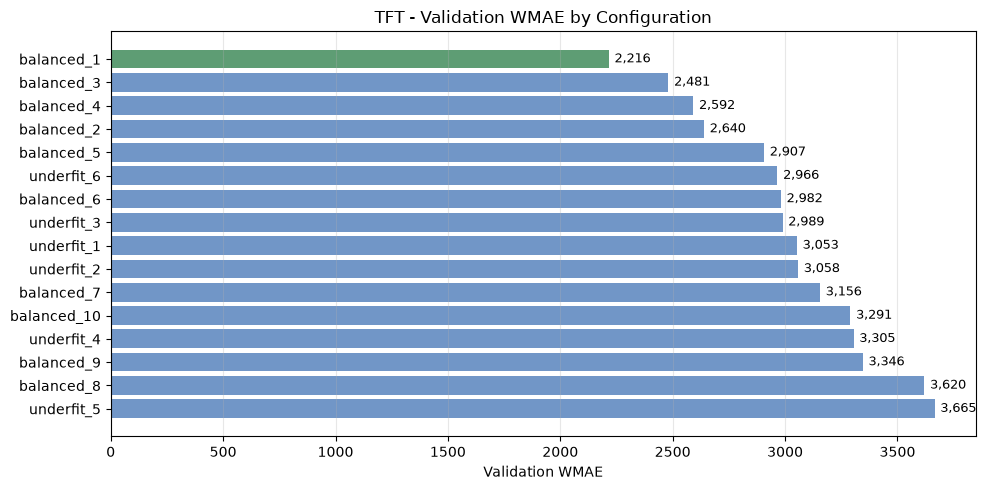

In [13]:
os.makedirs("Plots", exist_ok=True)
top_runs = results_df.sort_values("val_wmae").copy()
colors = top_runs["label"].map(lambda label: GREEN if label == best_label else BLUE)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_runs["label"], top_runs["val_wmae"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Validation WMAE")
ax.set_title("TFT - Validation WMAE by Configuration")
ax.grid(axis="x", alpha=0.3)
for idx, value in enumerate(top_runs["val_wmae"]):
    ax.text(value + 25, idx, f"{value:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plot_path = "Plots/tft_wmae_comparison.png"
plt.savefig(plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(plot_path)

wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT, name="TFT_Analysis", group="TFT", job_type="analysis", tags=["TFT", "analysis", "validation_wmae"], reinit=True)
wandb.log({"tft_wmae_comparison": wandb.Image(plot_path), "best_val_wmae": best_val_wmae})
wandb.finish()


### 13. Error Analysis

In [14]:
if "cv_by_label" in dir() and best_label in cv_by_label:
    best_cv_df = cv_by_label[best_label].copy()
else:
    best_cv_df = pd.read_parquet("reports/tft_best_cv.parquet")
best_cv_df["abs_error"] = (best_cv_df["y"] - best_cv_df[MODEL_COL]).abs()
best_cv_df[["Store", "Dept"]] = best_cv_df["unique_id"].str.split("_", n=1, expand=True)

display(best_cv_df.head())
worst_store_dept = best_cv_df.groupby(["Store", "Dept"])["abs_error"].mean().sort_values(ascending=False).head(15)
display(worst_store_dept)
holiday_error = best_cv_df.groupby("IsHoliday")["abs_error"].mean()
display(holiday_error)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_metric("holiday_week_mae", float(holiday_error.get(True, np.nan)))
    mlflow.log_metric("nonholiday_week_mae", float(holiday_error.get(False, np.nan)))

,unique_id,ds,cutoff,TFT,y,IsHoliday,abs_error,Store,Dept
0,10_1,2012-02-03,2012-01-27,39127.332031,36444.00,False,2683.332031,10,1
1,10_1,2012-02-10,2012-01-27,40346.253906,50434.11,True,10087.856094,10,1
2,10_1,2012-02-17,2012-01-27,37279.593750,74930.33,False,37650.736250,10,1
3,10_1,2012-02-24,2012-01-27,38658.949219,28751.57,False,9907.379219,10,1
4,10_1,2012-03-02,2012-01-27,40190.109375,30525.88,False,9664.229375,10,1


Store  Dept
14     92      26058.298045
10     72      25696.254447
14     95      20316.531554
28     92      20148.127620
14     72      19721.993646
20     72      19270.170184
35     72      18744.681711
14     38      14258.380152
       90      14244.669599
10     3       14232.542961
23     72      13953.562776
14     7       13939.521376
4      72      13710.698518
20     92      13463.342740
3      38      13235.005761
Name: abs_error, dtype: float64

IsHoliday
False    2079.361355
True     2722.473137
Name: abs_error, dtype: float64

### 14. Error Plots

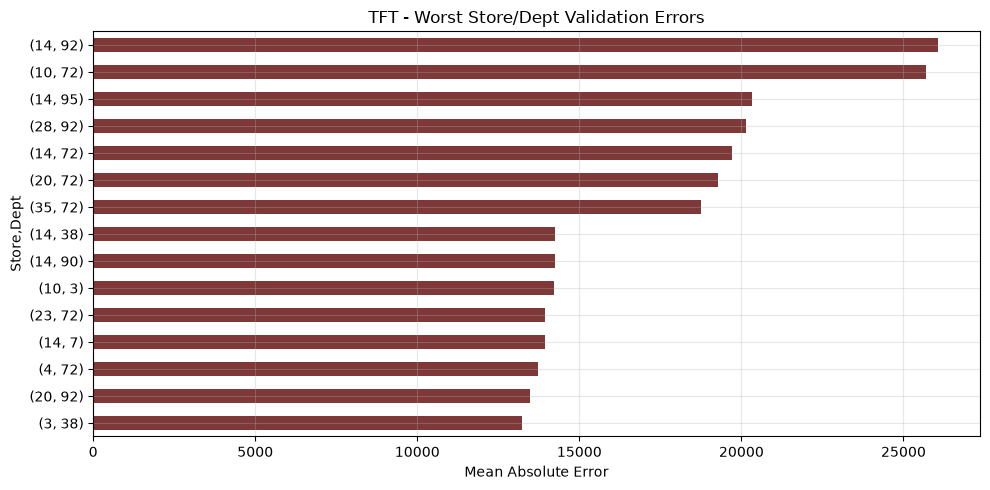

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
worst_store_dept.sort_values().plot(kind="barh", ax=ax, color=RED)
ax.set_xlabel("Mean Absolute Error")
ax.set_title("TFT - Worst Store/Dept Validation Errors")
ax.grid(True, alpha=0.3)
plt.tight_layout()
error_plot_path = "Plots/tft_worst_store_dept.png"
plt.savefig(error_plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(error_plot_path)

wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT, name="TFT_Error_Analysis", group="TFT", job_type="analysis", tags=["TFT", "error_analysis"], reinit=True)
wandb.log({"tft_worst_store_dept": wandb.Image(error_plot_path), "holiday_week_mae": float(holiday_error.get(True, np.nan)), "nonholiday_week_mae": float(holiday_error.get(False, np.nan))})
wandb.finish()


### 15. Best Model

In [16]:
print("Best label:", best_label)
print("Best run id:", best_run_id)
print("Best validation WMAE:", best_val_wmae)

best_row = results_df[results_df["label"] == best_label].iloc[0]
best_params = {key: best_row[key] for key in ["input_size", "hidden_size", "n_head", "dropout", "max_steps", "learning_rate", "batch_size"]}
best_params = {k: (int(v) if k not in ["dropout", "learning_rate"] else float(v)) for k, v in best_params.items()}
display(best_params)

fallback_by_id = long_df.sort_values("ds").groupby("unique_id")["y"].last().astype(float).to_dict()
global_fallback = float(long_df["y"].median())

# futr_cols (calendar/weather/economic/markdown/holiday) don't vary by Dept, but
# the real test set only has rows for weeks a department is active. Build a
# complete Store+Date reference table from features.csv so the pipeline can
# backfill exogenous values for dates a given store/dept series is missing.
store_date_features = build_store_date_features(load_features(), FUTR_COLS)

print(f"Fallback values available for {len(fallback_by_id)} series")
print(f"Global fallback Weekly_Sales: {global_fallback:,.2f}")

final_gradient_callback = GradientNormLogger(log_every_n_steps=10)

final_model = TFT(
    h=CONFIG["horizon"],
    input_size=best_params["input_size"],
    futr_exog_list=FUTR_COLS,
    stat_exog_list=STATIC_COLS,
    hidden_size=best_params["hidden_size"],
    n_head=best_params["n_head"],
    dropout=best_params["dropout"],
    max_steps=best_params["max_steps"],
    learning_rate=best_params["learning_rate"],
    batch_size=best_params["batch_size"],
    random_seed=CONFIG["random_seed"],
    scaler_type="standard",
    accelerator="gpu",
    devices=1,
    callbacks=[final_gradient_callback],
)
final_nf = NeuralForecast(models=[final_model], freq=FREQ)

final_nf.fit(df=tft_df, static_df=static_df)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_param("registered_model_name", "TFT_WalmartForecast")
    mlflow.log_metric("best_train_wmae", float(best_row["train_wmae"]))
    mlflow.log_metric("best_val_wmae", best_val_wmae)
    mlflow.log_metric("best_gap_pct", float(best_row["gap_pct"]))
    mlflow.log_param("best_fit_status", best_row["fit_status"])
    mlflow.log_param("future_exogenous_columns", ",".join(FUTR_COLS))
    mlflow.log_param("static_exogenous_columns", ",".join(STATIC_COLS))
    mlflow.log_param("n_futr_cols", len(FUTR_COLS))
    mlflow.log_param("n_static_cols", len(STATIC_COLS))
    mlflow.log_param("fallback_method", "last_observed_sales_by_store_dept")
    mlflow.log_metric("global_fallback_weekly_sales", global_fallback)
    mlflow.log_params({f"final_{k}": v for k, v in best_params.items()})
    mlflow.log_param("final_gradient_logging", True)

    log_gradient_diagnostics(
        final_gradient_callback,
        model_name="TFT",
        run_label=f"final_{best_label}",
        mlflow_module=mlflow,
        wandb_module=None,
    )

# Otherwise Lightning tries to save GradientNormLogger object to YAML
for model in final_nf.models:
    strip_neuralforecast_callbacks(model)

os.makedirs("artifacts", exist_ok=True)
best_nf_path = f"artifacts/tft_final_{best_label}"
save_neuralforecast_model(final_nf, path=best_nf_path, overwrite=True)

print("Final NeuralForecast model saved to:", best_nf_path)

pipeline_model = TFTForecastPipeline(model_col=MODEL_COL, futr_cols=FUTR_COLS, static_cols=STATIC_COLS, fallback_by_id=fallback_by_id, global_fallback=global_fallback, store_date_features=store_date_features)

class _SignatureContext:
    artifacts = {"nf_model_dir": best_nf_path}

_temp = TFTForecastPipeline(model_col=MODEL_COL, futr_cols=FUTR_COLS, static_cols=STATIC_COLS, fallback_by_id=fallback_by_id, global_fallback=global_fallback, store_date_features=store_date_features)
_temp.load_context(_SignatureContext())
sample_output = _temp.predict(_SignatureContext(), test_df)
signature = infer_signature(test_df, sample_output)
display(sample_output.head())

with mlflow.start_run(run_id=best_run_id):
    logged_model_info = mlflow.pyfunc.log_model(
        artifact_path="pipeline",
        python_model=pipeline_model,
        artifacts={"nf_model_dir": best_nf_path},
        code_paths=[str(repo_root / "src")],
        signature=signature,
        input_example=test_df.head(20),
        registered_model_name="TFT_WalmartForecast",
    )

model_uri = logged_model_info.model_uri
print("Logged model URI:", model_uri)


Best label: balanced_1
Best run id: c8417033444347c6a7d7f5f08a464a0c
Best validation WMAE: 2216.193649301574


{'input_size': 52,
 'hidden_size': 32,
 'n_head': 2,
 'dropout': 0.1,
 'max_steps': 300,
 'learning_rate': 0.001,
 'batch_size': 128}

Fallback values available for 3331 series
Global fallback Weekly_Sales: 7,612.03
Final NeuralForecast model saved to: artifacts/tft_final_balanced_1


,Id,Weekly_Sales
0,1_1_2012-11-02,35603.539062
1,1_1_2012-11-09,33125.390625
2,1_1_2012-11-16,37764.437500
3,1_1_2012-11-23,22999.447266
4,1_1_2012-11-30,38424.074219


Logged model URI: models:/m-8d6a32209d064cef8ca76067aa6af697


### 16. Test Loading

In [17]:
loaded_model = mlflow.pyfunc.load_model(model_uri)
loaded_preds = loaded_model.predict(test_df)
display(loaded_preds.head())
print("Loaded prediction shape:", loaded_preds.shape)
assert set(loaded_preds.columns) == {"Id", "Weekly_Sales"}
assert loaded_preds["Weekly_Sales"].notna().all()


,Id,Weekly_Sales
0,1_1_2012-11-02,35603.539062
1,1_1_2012-11-09,33125.390625
2,1_1_2012-11-16,37764.437500
3,1_1_2012-11-23,22999.447266
4,1_1_2012-11-30,38424.074219


Loaded prediction shape: (115064, 2)
